In [1]:
import numpy as np
import pandas as pd
import gc
from sklearn import preprocessing
from IPython.display import clear_output
from sklearn.linear_model import Ridge, Lasso, ElasticNet, RidgeCV, ElasticNetCV, LassoCV
from sklearn.linear_model import LinearRegression
from utils.age_utils import transform_age, anti_transform_age
from utils.metrics import evaluate_age_prediction
import matplotlib.pyplot as plt
import xgboost as xgb

In [2]:
geo_data_27k = [
    'GSE27317',
    'GSE41037',
    'GSE38873',
    'GSE15745',
    'GSE32393',
    'GSE25892',
    'GSE20242',
    'GSE22595',
    'GSE37988',
    'GSE17448',
    'GSE36642',
    'GSE26126',
    'GSE34035',
    'GSE28746',
    'GSE20236',
    'GSE19711',
    'GSE37008',
    'GSE36812',
    'GSE34257',
    'GSE38608',
    'GSE38291',
    'GSE36166',
    'GSE63384',
    'GSE59274',
    'GSE57285',
    'GSE56606',
    'GSE49908',
    'GSE49907',
    'GSE49905',
    'GSE49904'
]

geo_data_450k = [
    'GSE90124',
    'GSE115797',
    'GSE99624',
    'GSE108213',
    'GSE92767',
    'GSE69176',
    'GSE40360',
    'GSE59157',
    'GSE42861',
    'GSE77241',
    'GSE148000'
]

array_express_27k = [
    'E-GEOD-43256',
    'E-GEOD-64940',
    'E-MTAB-2344',
    'E-GEOD-62867',
    'E-GEOD-44763',
    'E-GEOD-48988',
    'E-GEOD-58119',
    'E-GEOD-58045',
    'E-GEOD-57484',
    'E-GEOD-54211',
    'E-GEOD-56342',
    'E-GEOD-27044',
    'E-GEOD-36194',
    'E-GEOD-21232',
    'E-GEOD-32867',
    'E-GEOD-30759',
    'E-GEOD-30758',
    'E-GEOD-32396',
    'E-GEOD-31979',
    'E-MTAB-625',
    'E-MTAB-487'
]

array_express_450k = [
    'E-MTAB-2372',
    'E-GEOD-73832',
    'E-GEOD-71678',
    'E-GEOD-71245',
    'E-GEOD-83334',
    'E-GEOD-75248',
    'E-GEOD-77955',
    'E-GEOD-67705',
    'E-GEOD-77445',
    'E-GEOD-79056',
    'E-GEOD-72556',
    'E-GEOD-52068',
    'E-GEOD-74738',
    'E-GEOD-76105',
    'E-GEOD-65638',
    'E-GEOD-71955',
    'E-GEOD-63106',
    'E-GEOD-73377',
    'E-GEOD-56515',
    'E-GEOD-73103',
    'E-GEOD-67024',
    'E-GEOD-72338',
    'E-GEOD-59457',
    'E-GEOD-64511',
    'E-GEOD-64495',
    'E-GEOD-59509',
    'E-GEOD-67444',
    'E-GEOD-62219',
    'E-GEOD-51954',
    'E-GEOD-52588',
    'E-GEOD-36054',
    'E-GEOD-50660',
    'E-GEOD-61259',
    'E-GEOD-61258',
    'E-GEOD-61257',
    'E-GEOD-61454',
    'E-GEOD-61380',
    'E-GEOD-61107',
    'E-GEOD-54690',
    'E-GEOD-49149',
    'E-GEOD-55438',
    'E-GEOD-53740',
    'E-GEOD-57767',
    'E-GEOD-49064',
    'E-GEOD-50759',
    'E-GEOD-56553',
    'E-GEOD-54399',
    'E-GEOD-53162',
    'E-GEOD-53128',
    'E-GEOD-50498',
    'E-GEOD-47513',
    'E-GEOD-49393',
    'E-GEOD-39004',
    'E-GEOD-51388',
    'E-GEOD-51032',
    'E-GEOD-48325',
    'E-GEOD-44712',
    'E-GEOD-45461',
    'E-GEOD-40279',
    'E-GEOD-41169',
    'E-GEOD-32149',
    'E-GEOD-41826',
    'E-GEOD-42700',
    'E-GEOD-32146',
    'E-GEOD-30870',
    'E-GEOD-34639',
    'E-GEOD-63347',
    'E-GEOD-59592'
]

tcga_all = [
    'TGCA_LUSC',
    'TGCA_THCA',
    'TGCA_HNSC',
    'TGCA_KIRC',
    'TGCA_KIRP',
    'TGCA_LUAD',
    'TGCA_PRAD',
    'TGCA_STAD',
    'TGCA_COAD',
    'TGCA_LIHC',
    'TGCA_UCEC',
    'TGCA_BRCA'
]

cancer_data = [
    'GSE32393',
    'GSE37988',
    'GSE26126',
    'GSE63384',
    'GSE59157',
    'E-GEOD-32867',
    'E-GEOD-30759',
    'E-GEOD-31979',
    'E-GEOD-77955',
    'E-GEOD-52068',
    'E-GEOD-49149',
    'E-GEOD-39004'
]

cancer_comparison = [
    'GSE53051',
]

reliability = [
    'GSE55763',
]

rejuvenation = [
    'GSE142439',
    'GSE116754',
    'GSE65214',
    'GSE44430',
    'GSE45727',
    'GSE30653',
    'GSE37066',
    'GSE30456',
]

senescence_analysis = [
    'GSE91069',
    'GSE100249'
]

data_27k = np.concatenate([np.array(geo_data_27k), np.array(array_express_27k)])
data_450k = np.concatenate([np.array(geo_data_450k), np.array(array_express_450k)])
geo_data = np.concatenate([data_27k, data_450k])
tcga_all = np.array(tcga_all)
all_data = np.concatenate([data_27k, data_450k, tcga_all])

#load all train data for model training
count = 0
for dataset in all_data:
    print(dataset)
    if count == 0:
        all_train = pd.read_pickle('../data_train/' + dataset + '.pkl')
        count += 1
    else:
        new_df = pd.read_pickle('../data_train/' + dataset + '.pkl')
        all_train = pd.concat([all_train, new_df], join ='inner')
        gc.collect()
    clear_output()

#load all test data
count = 0
for dataset in all_data:
    print(dataset)
    if count == 0:
        all_test = pd.read_pickle('../data_test/' + dataset + '.pkl')
        count += 1
    else:
        new_df = pd.read_pickle('../data_test/' + dataset + '.pkl')
        all_test = pd.concat([all_test, new_df], join ='inner')
        gc.collect()
    clear_output()


    multi_platform_cpgs = np.array(pd.read_pickle('../dependencies/multi_platform_cpgs.pkl'))

#extracting age and removing unimportant columns
train_ages = all_train['age'].astype('float64')
test_ages = all_test['age'].astype('float64')

train_info = all_train[['dataset', 'tissue_type', 'age', 'gender']]
test_info = all_test[['dataset', 'tissue_type', 'age', 'gender']]

train = all_train[multi_platform_cpgs]
test = all_test[multi_platform_cpgs]

train_cols = train.columns
train_index = train.index

test_cols = test.columns
test_index = test.index

#scaling the data so each columns has 0 mean and variance 1
scaler = preprocessing.RobustScaler()

train_scaled = pd.DataFrame(scaler.fit_transform(train), index = train_index, columns = train_cols)
test_scaled = pd.DataFrame(scaler.transform(test), index = test_index, columns = test_cols)

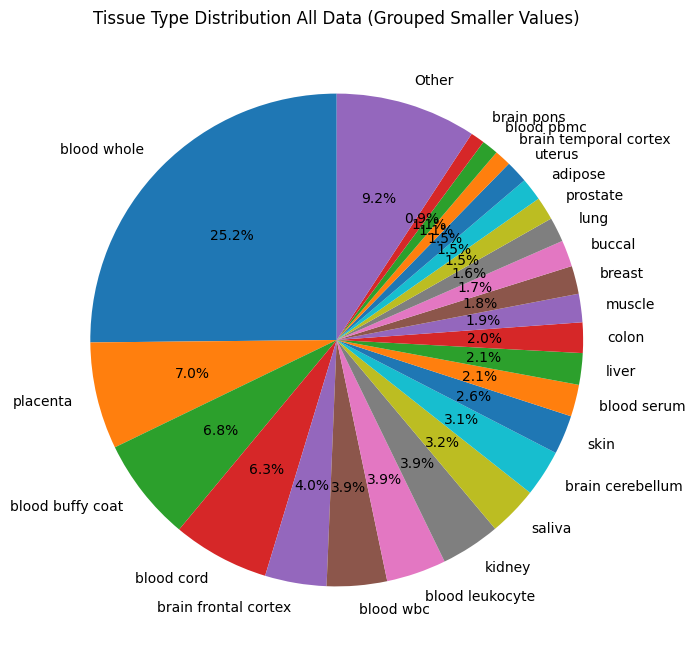

In [66]:
import matplotlib.pyplot as plt

threshold = 100
tissue_counts = train_info['tissue_type'].value_counts() + test_info['tissue_type'].value_counts()
tissue_counts_grouped = tissue_counts[tissue_counts >= threshold]

# Calculate 'Other' before sorting
other_count = tissue_counts[tissue_counts < threshold].sum()

# Sort main values (excluding 'Other')
tissue_counts_sorted = tissue_counts_grouped.sort_values(ascending=False)

# Append 'Other' at the end
tissue_counts_sorted['Other'] = other_count

# Plot the pie chart
tissue_counts_sorted.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    figsize=(8, 8),
    labels=tissue_counts_sorted.index
)
plt.title("Tissue Type Distribution All Data (Grouped Smaller Values)")
plt.ylabel("")
plt.show()


In [3]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=350)  # or percentile=1%
X_selected = selector.fit_transform(train_scaled, train_ages)
selected_cpgs = train_scaled.columns[selector.get_support()]

## Linear regression

In [14]:
linear_regression_model = LinearRegression()
linear_regression_model.fit(train_scaled, transform_age(train_ages))

predicted_ages = anti_transform_age(linear_regression_model.predict(test_scaled))

results_linear = evaluate_age_prediction(test_ages, predicted_ages, cpg_count=len(train_cols), model_name="Linear Regression")
print(results_linear.round(3))

               Model   CpGs    MAD    MAE    MSE  Pearson R  Median Error
0  Linear Regression  20318  3.329  5.086  60.68      0.959         0.035


In [13]:
ridgeCV_scaled = RidgeCV(alphas=[0.1, 1, 10, 100, 200], cv=5)
ridgeCV_scaled.fit(train_scaled, transform_age(train_ages))
print("Best alpha:", ridgeCV_scaled.alpha_)

ridgeCV_predictions_scaled = anti_transform_age(ridgeCV_scaled.predict(test_scaled))

results_ridge_CV_scaled = evaluate_age_prediction(test_ages, ridgeCV_predictions_scaled, model_name="RidgeCV scaled", cpg_count=len(train_cols))
print(results_ridge_CV_scaled.round(3))

Best alpha: 200
            Model   CpGs   MAD    MAE    MSE  Pearson R  Median Error
0  RidgeCV scaled  20318  2.96  4.476  47.47      0.968         0.024


In [5]:
lasso_cv_scaled = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10], cv=5)
lasso_cv_scaled.fit(train_scaled, transform_age(train_ages))

lassoCV_predictions_scaled = anti_transform_age(lasso_cv_scaled.predict(test_scaled))

results_lassoCV_scaled = evaluate_age_prediction(test_ages, lassoCV_predictions_scaled, model_name="LassoCV", cpg_count=np.sum(lasso_cv_scaled.coef_ != 0))
print(results_lassoCV_scaled.round(3))

print("Best alpha:", lasso_cv_scaled.alpha_)

C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.593e+01, tolerance: 2.440e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.154e+01, tolerance: 2.440e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

     Model  CpGs    MAD    MAE     MSE  Pearson R  Median Error
0  LassoCV  3967  2.753  4.169  42.767      0.971         0.027
Best alpha: 0.001


In [6]:
elastic_cv = ElasticNetCV(
    alphas=[0.001, 0.01, 0.1],
    l1_ratio=[0.2, 0.5, 0.7],
    cv=5,
    max_iter=1000
)
elastic_cv.fit(train_scaled, transform_age(train_ages))

elasticCV_pred_scaled = anti_transform_age(elastic_cv.predict(test_scaled))

results_elasticCV = evaluate_age_prediction(test_ages, elasticCV_pred_scaled, model_name="ElasticNetCV", cpg_count=np.sum(elastic_cv.coef_ != 0))
print(results_elasticCV.round(3))

print("Best alpha:", elastic_cv.alpha_)
print("Best l1_ratio:", elastic_cv.l1_ratio_)

C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.293e+01, tolerance: 2.440e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.444e+01, tolerance: 2.440e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

          Model  CpGs   MAD   MAE     MSE  Pearson R  Median Error
0  ElasticNetCV  2551  2.62  3.97  38.401      0.974         0.016
Best alpha: 0.01
Best l1_ratio: 0.2


## XGBoost

In [7]:
xgboost_best_param = xgb.XGBRegressor(
    tree_method='hist',
    device = 'cuda',
    predictor='gpu_predictor',
    n_estimators=500,
    max_depth=5,
    learning_rate=0.1
)

xgboost_best_param.fit(train_scaled, transform_age(train_ages))

result_best_param = anti_transform_age(xgboost_best_param.predict(test_scaled))

res_best_param = evaluate_age_prediction(test_ages, result_best_param, model_name="XGBoost", cpg_count=len(xgboost_best_param.get_booster().get_score(importance_type='weight')))
print(res_best_param.round(3))

C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:04:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:729: UserWarning: [23:09:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


     Model  CpGs    MAD   MAE     MSE  Pearson R  Median Error
0  XGBoost  8444  2.996  4.51  47.426      0.968         0.007


## Feature selection

In [8]:
elasticNet = ElasticNet(alpha=0.01, l1_ratio=0.2)
elasticNet.fit(train_scaled[selected_cpgs], transform_age(train_ages))

elasticNet_predictions = anti_transform_age(elasticNet.predict(test_scaled[selected_cpgs]))

results_elasticNet = evaluate_age_prediction(test_ages, elasticNet_predictions, model_name="ElasticNet", cpg_count=np.sum(elasticNet.coef_ != 0))
print(results_elasticNet.round(3))

        Model  CpGs    MAD   MAE     MSE  Pearson R  Median Error
0  ElasticNet   262  3.485  5.36  66.173      0.955        -0.004


C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.659e+02, tolerance: 2.983e+00
  model = cd_fast.enet_coordinate_descent(


In [9]:
from sklearn.feature_selection import RFE

# Base model
elastic_net_rfe = ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=42)

# RFE: Select top N features
selector_elas = RFE(estimator=elastic_net_rfe, n_features_to_select=350, step=0.1)
selector_elas.fit(train_scaled, transform_age(train_ages))

# Get selected features
train_selected_rfe = selector_elas.transform(train_scaled)
test_selected_rfe = selector_elas.transform(test_scaled)

# Optionally refit model
elastic_net_rfe.fit(train_selected_rfe, transform_age(train_ages))

elastic_predictions_rfe = anti_transform_age(elastic_net_rfe.predict(test_selected_rfe))

results_elastic_net = evaluate_age_prediction(test_ages, elastic_predictions_rfe, model_name="ElasticNet(RFE)", cpg_count=np.sum(elastic_net_rfe.coef_ != 0))
print(results_elastic_net.round(3))

C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.812e+02, tolerance: 2.983e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.662e+02, tolerance: 2.983e+00
  model = cd_fast.enet_coordinate_descent(
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

             Model  CpGs   MAD    MAE     MSE  Pearson R  Median Error
0  ElasticNet(RFE)   341  2.82  4.264  44.085       0.97        -0.013


C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.954e+02, tolerance: 2.983e+00
  model = cd_fast.enet_coordinate_descent(


In [10]:
xgboost_best_param = xgb.XGBRegressor(
    tree_method='hist',
    device = 'cuda',
    predictor='gpu_predictor',
    n_estimators=500,
    max_depth=5,
    learning_rate=0.1
)

xgboost_best_param.fit(train_scaled[selected_cpgs], transform_age(train_ages))

result_best_param = anti_transform_age(xgboost_best_param.predict(test_scaled[selected_cpgs]))

res_best_param = evaluate_age_prediction(test_ages, result_best_param, model_name="XGBoost(SKB)", cpg_count=len(xgboost_best_param.get_booster().get_score(importance_type='weight')))
print(res_best_param.round(3))

C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:16:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          Model  CpGs    MAD   MAE     MSE  Pearson R  Median Error
0  XGBoost(SKB)   350  3.094  4.59  48.965      0.967         0.004


In [11]:
import xgboost as xgb
xgboost = xgb.XGBRegressor(
    tree_method='hist',
    device = 'cuda',
    predictor='gpu_predictor',
    n_estimators=500,
    max_depth=5,
    learning_rate=0.1
)

# RFE: Select top N features
selector = RFE(estimator=xgboost, n_features_to_select=350, step=0.1)
selector.fit(train_scaled, transform_age(train_ages))

# Get selected features
train_selected = selector.transform(train_scaled)
test_selected = selector.transform(test_scaled)

xgboost.fit(train_selected, transform_age(train_ages))

xgboost_pred = anti_transform_age(xgboost.predict(test_selected))

results_xgboost = evaluate_age_prediction(test_ages, xgboost_pred, model_name="XGboost(RFE)", cpg_count=len(xgboost.get_booster().get_score(importance_type='weight')))
print(results_xgboost.round(3))

C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:17:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:22:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:26:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\elena\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:30:48] WARNING: C:\actions-runner\_work\xgboost\

          Model  CpGs    MAD    MAE     MSE  Pearson R  Median Error
0  XGboost(RFE)   350  3.029  4.423  45.307      0.969         0.006


# SHAP analysis

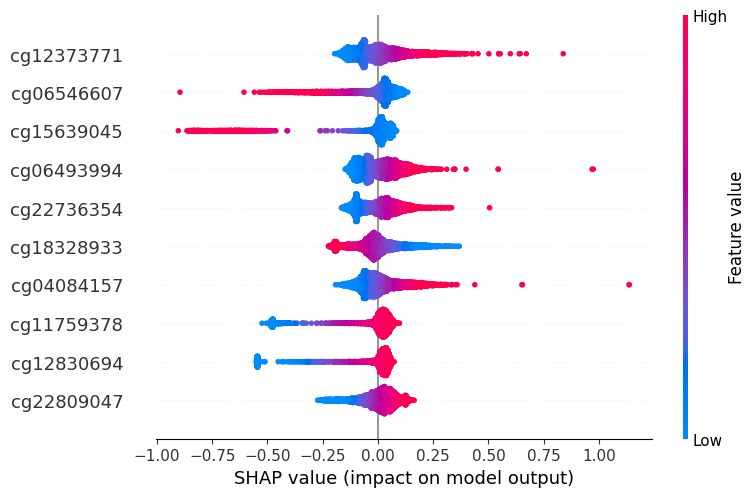

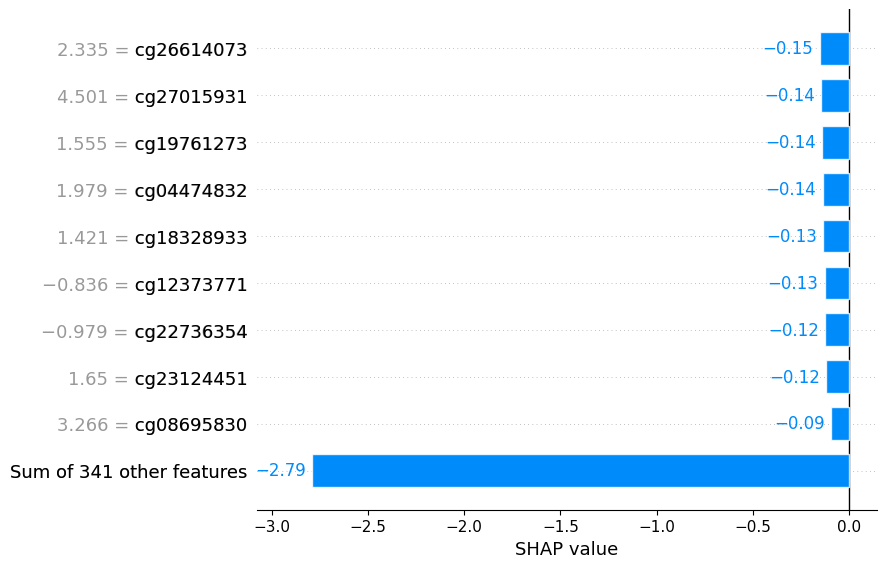

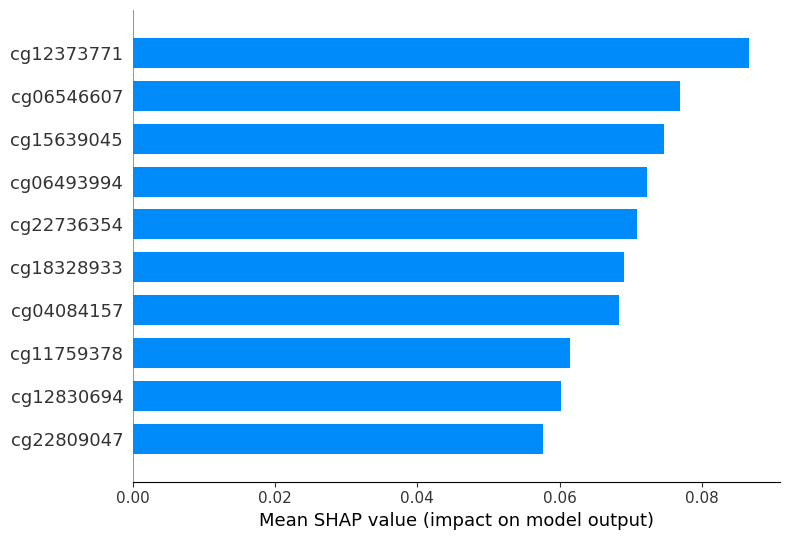

['cg00075967', 'cg00091693', 'cg00168942', 'cg00211661', 'cg00226904', 'cg00374717', 'cg00515905', 'cg00688421', 'cg00739120', 'cg00810473', 'cg01087382', 'cg01137065', 'cg01154193', 'cg01169610', 'cg01195053', 'cg01262913', 'cg01459453', 'cg01635061', 'cg01957330', 'cg01968178', 'cg02009694', 'cg02131399', 'cg02153528', 'cg02154074', 'cg02166313', 'cg02228185', 'cg02335441', 'cg02425732', 'cg02479575', 'cg02712165', 'cg02789485', 'cg02913089', 'cg03011500', 'cg03019000', 'cg03167275', 'cg03192551', 'cg03330058', 'cg03359508', 'cg03634997', 'cg03760483', 'cg03833068', 'cg03876618', 'cg03975694', 'cg04084157', 'cg04126866', 'cg04211818', 'cg04456238', 'cg04474832', 'cg04528819', 'cg04784672', 'cg04836038', 'cg04865575', 'cg04884122', 'cg04916911', 'cg04999691', 'cg05149586', 'cg05250458', 'cg05294243', 'cg05442902', 'cg05473871', 'cg05655556', 'cg05751979', 'cg05895453', 'cg06144905', 'cg06251129', 'cg06493994', 'cg06546607', 'cg06580318', 'cg06993413', 'cg07047653', 'cg07102705', 'cg07

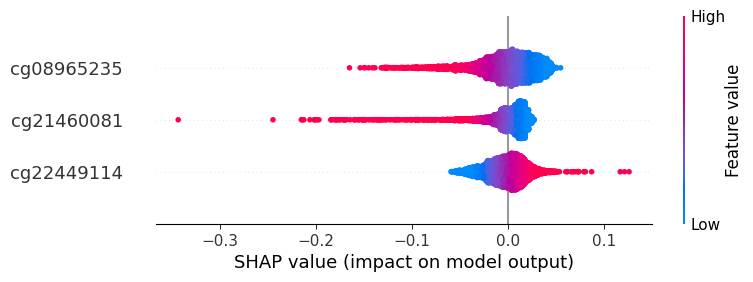

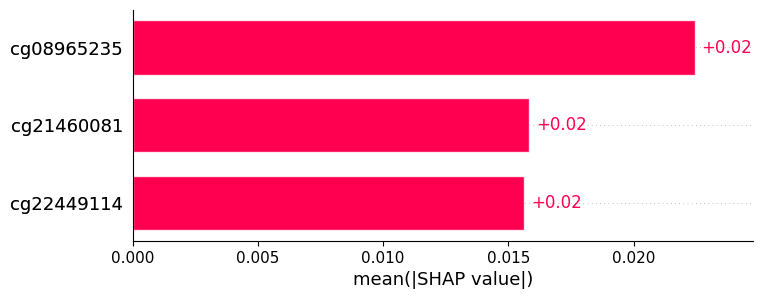

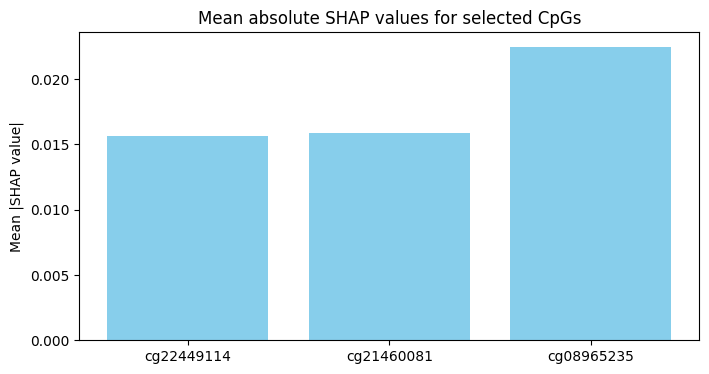

In [121]:
import shap

rfe_selected_feature_names = train.columns[selector_elas.support_]

explainer_linear = shap.LinearExplainer(elastic_net_rfe, train_selected_rfe, feature_names=rfe_selected_feature_names)
shap_values_rfe = explainer_linear(test_selected_rfe)

shap.plots.beeswarm(shap_values_rfe, max_display=10, group_remaining_features=False)

shap.plots.bar(shap_values_rfe[0], max_display=10)

shap.summary_plot(shap_values_rfe, test_selected_rfe, plot_type="bar", show=False, max_display=10)
plt.xlabel("Mean SHAP value (impact on model output)")
plt.show()

print(shap_values_rfe.feature_names)

# Your original selected features
selected_features = ['cg22449114', 'cg21460081', 'cg08965235']

# Convert feature names to list (if needed)
feature_names_list = list(shap_values_rfe.feature_names)

# Get indices for selected features
selected_indices = [feature_names_list.index(f) for f in selected_features]

# Extract corresponding SHAP values and data
subset_values = shap_values_rfe.values[:, selected_indices]
subset_data = shap_values_rfe.data[:, selected_indices]

# Create new Explanation object for the subset
shap_subset = shap.Explanation(
    values=subset_values,
    base_values=shap_values_rfe.base_values,
    data=subset_data,
    feature_names=selected_features
)

# Plot beeswarm with exactly these features, no max_display needed
shap.plots.beeswarm(shap_subset, group_remaining_features=False)
plt.show()

shap.plots.bar(shap_subset)

mean_abs_shap = np.mean(np.abs(subset_values), axis=0)

# 3. Plot bar chart of mean absolute SHAP values
plt.figure(figsize=(8,4))
plt.bar(selected_features, mean_abs_shap, color='skyblue')
plt.ylabel('Mean |SHAP value|')
plt.title('Mean absolute SHAP values for selected CpGs')
plt.show()


In [116]:
import pandas as pd
import numpy as np

# Mean SHAP values (absolute)
mean_abs_shap = np.abs(shap_values_rfe.values).mean(axis=0)

# Create DataFrame
shap_importance = pd.DataFrame({
    'feature': rfe_selected_feature_names,
    'mean_abs_shap': mean_abs_shap
})

# Sort by importance
shap_importance.sort_values(by='mean_abs_shap', ascending=False, inplace=True)

# Normalize and compute cumulative contribution
shap_importance['contribution_percent'] = shap_importance['mean_abs_shap'] / shap_importance['mean_abs_shap'].sum()
shap_importance['cumulative_percent'] = shap_importance['contribution_percent'].cumsum()

# Show top features up to 80% cumulative contribution
important_features = shap_importance[shap_importance['cumulative_percent'] <= 0.80]

print(important_features)
print(important_features['feature'].to_list)
print(important_features.shape)

important_features.to_csv("80_percent_features.csv", index=False)


        feature  mean_abs_shap  contribution_percent  cumulative_percent
142  cg12373771       0.086659              0.012451            0.012451
66   cg06546607       0.076866              0.011044            0.023495
189  cg15639045       0.074723              0.010736            0.034231
65   cg06493994       0.072350              0.010395            0.044627
283  cg22736354       0.070940              0.010193            0.054819
..          ...            ...                   ...                 ...
233  cg18573383       0.016254              0.002335            0.790310
331  cg26244225       0.016073              0.002309            0.792620
33   cg03019000       0.016009              0.002300            0.794920
241  cg19553056       0.015990              0.002297            0.797217
319  cg25290938       0.015977              0.002296            0.799513

[195 rows x 4 columns]
<bound method IndexOpsMixin.tolist of 142    cg12373771
66     cg06546607
189    cg15639045
65     c

In [110]:
mean_abs_shap = np.abs(shap_values_rfe.values).mean(axis=0)
importance_ratio = mean_abs_shap / mean_abs_shap.sum()

# Show features contributing more than 1% of total importance
important_features = importance_ratio > 0.01
num_important = important_features.sum()
print(f"Number of important features: {num_important}")

Number of important features: 5


## Overlap with Horvath

In [13]:
coeff_df = pd.read_csv("../dependencies/horvath_cpg.csv", skiprows=2)  # skip rows for metadata above the header

# Get the list of CpG IDs (excluding the intercept row)
horvath_cpg_list = coeff_df['CpGmarker'].dropna().tolist()
horvath_cpgs = [cpg for cpg in horvath_cpg_list if cpg != '(Intercept)']

train_horvath = all_train[horvath_cpgs]
test_horvath = all_test[horvath_cpgs]

train_cols_horvath = train_horvath.columns
train_index_horvath = train_horvath.index

test_cols_horvath = test_horvath.columns
test_index_horvath = test_horvath.index

In [14]:
# Get mask of non-zero coefficients
nonzero_mask = elastic_net_rfe.coef_ != 0

rfe_selected_feature_names = train.columns[selector_elas.support_]

nonzero_cpg_names = rfe_selected_feature_names[nonzero_mask]

overlapping_cpgs = list(set(nonzero_cpg_names) & set(horvath_cpgs))

print(f"Number of overlapping CpGs: {len(overlapping_cpgs)}")
print("Overlapping CpGs:", overlapping_cpgs)

Number of overlapping CpGs: 95
Overlapping CpGs: ['cg14424579', 'cg22449114', 'cg27169020', 'cg25505610', 'cg01968178', 'cg05294243', 'cg08186124', 'cg07408456', 'cg04836038', 'cg03760483', 'cg05250458', 'cg15547534', 'cg26614073', 'cg01459453', 'cg10865119', 'cg27015931', 'cg11299964', 'cg03330058', 'cg15804973', 'cg04126866', 'cg09118625', 'cg25148589', 'cg21801378', 'cg04474832', 'cg07730301', 'cg17338403', 'cg02335441', 'cg06493994', 'cg22809047', 'cg08370996', 'cg25781123', 'cg24058132', 'cg00374717', 'cg08965235', 'cg22947000', 'cg24081819', 'cg13836627', 'cg17063929', 'cg04528819', 'cg12941369', 'cg14894144', 'cg16547529', 'cg14175438', 'cg00075967', 'cg13460409', 'cg20692569', 'cg03019000', 'cg08030082', 'cg22197830', 'cg26372517', 'cg25771195', 'cg17729667', 'cg05442902', 'cg10523019', 'cg19761273', 'cg16744741', 'cg09809672', 'cg07388493', 'cg23124451', 'cg12373771', 'cg08413469', 'cg18440048', 'cg20761322', 'cg09722555', 'cg16408394', 'cg14060828', 'cg15988232', 'cg06993413'

In [44]:
overlapping_df = shap_df[shap_df['Feature'].isin(overlapping_cpgs)]

# Step 4: Compute percentage contribution of overlapping features
total_shap = shap_df['Mean |SHAP|'].sum()
overlap_shap = overlapping_df['Mean |SHAP|'].sum()
overlap_percentage = (overlap_shap / total_shap) * 100

print(f"Overlapping CpG SHAP contribution: {overlap_percentage:.2f}%")

Overlapping CpG SHAP contribution: 35.33%


In [15]:
import pandas as pd

# Load the annotation file
df_annot = pd.read_csv("../dependencies/GPL13534-11288.txt", comment='#', sep='\t')

# Ensure 'ID' column is string type
df_annot['ID'] = df_annot['ID'].astype(str)

# Filter to only overlapping CpGs
overlapping_genes_df = df_annot[df_annot['ID'].isin(overlapping_cpgs)]

# Create a new DataFrame with CpG IDs and associated genes
# Optionally split multiple gene entries and keep mapping
cpg_gene_table = []

for _, row in overlapping_genes_df.iterrows():
    cpg_id = row['ID']
    genes = str(row['UCSC_RefGene_Name'])
    if pd.notna(genes):
        for gene in genes.split(';'):
            gene = gene.strip()
            if gene:
                cpg_gene_table.append({'CpG_ID': cpg_id, 'Gene': gene})

# Convert to DataFrame
cpg_gene_df = pd.DataFrame(cpg_gene_table)

# Optional: remove duplicates
cpg_gene_df = cpg_gene_df.drop_duplicates()

grouped_df = cpg_gene_df.groupby('CpG_ID')['Gene'].apply(lambda genes: ';'.join(sorted(set(genes)))).reset_index()

# Display the table
print(grouped_df)
# Save grouped format to CSV
grouped_df.to_csv("cpg_gene_mapping_grouped.csv", index=False)


C:\Users\elena\AppData\Local\Temp\ipykernel_27220\4107529199.py:4: DtypeWarning: Columns (11,14,15,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_annot = pd.read_csv("../dependencies/GPL13534-11288.txt", comment='#', sep='\t')


        CpG_ID                Gene
0   cg00075967               STRA6
1   cg00091693               KRT20
2   cg00374717                ARSG
3   cg01262913               DSCR9
4   cg01459453                SELP
..         ...                 ...
90  cg26394940  C22orf26;LOC150381
91  cg26614073                SCAP
92  cg27015931            C16orf65
93  cg27169020                BNC1
94  cg27544190            C21orf63

[95 rows x 2 columns]


In [4]:
import pandas as pd

# Load the annotation file, skipping commented lines
df_annot = pd.read_csv("../dependencies/GPL13534-11288.txt", comment='#', sep='\t')

# Ensure the UCSC_RefGene_Name column is treated as string
df_annot['UCSC_RefGene_Name'] = df_annot['UCSC_RefGene_Name'].astype(str)

# Create an empty set to collect unique genes
all_genes_set = set()

# Iterate through the column and split gene names by semicolon
for genes in df_annot['UCSC_RefGene_Name']:
    if pd.notna(genes):
        for gene in genes.split(';'):
            gene = gene.strip()
            if gene:
                all_genes_set.add(gene)

# Convert to a sorted list
all_genes = sorted(all_genes_set)

# Display the number and a preview
print(f"Total unique genes: {len(all_genes)}")
print(all_genes[:10])  # Show first 10 genes

# Save to CSV
pd.DataFrame(all_genes, columns=['Gene']).to_csv("all_genes_from_annotation.csv", index=False)


C:\Users\elena\AppData\Local\Temp\ipykernel_27220\935598963.py:4: DtypeWarning: Columns (11,14,15,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_annot = pd.read_csv("../dependencies/GPL13534-11288.txt", comment='#', sep='\t')


Total unique genes: 21228
['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT', 'AAA1', 'AAAS']
